# 1. Introdução
# Engenharia de Variáveis
## Projeto: Credit Risk - Home Credit Default Risk

Este Notebook tem como objetivo realizar a etapa de Engenharia de Variáveis, transformando os dados brutos em um conjunto de features adequado para a construção de modelos preditivos de risco de crédito.

As decisões adotadas nesta etapa são fundamentadas nos insights obtidos durante a Análise Explorátoria de Dados (EDA), buscando equilibrar desempenho, robustez e interpretabilidade do modelo.

# 2. Escopo e Estratégia de Engenharia de Variáveis

Nesta etapa inicial da engenharia de variáveis, o foca será a base 'application_train.csv', considerando um escopo incremental para o projeto.

As principais diretrizes adotadas incluem:
- Manutenção de variáveis com potencial informativo
- Tratamento consicente de valores ausentes
- Preparação das variáveis para modelos lineares
- Priorização de interpretabilidade

# 3. Importação de Bibliotecas e Configurações Iniciais 

In [59]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# 4. Carregamento dos Dados

In [124]:
application_train = pd.read_csv('../data/application_train.csv', encoding = 'iso-8859-1')
application_train.shape

(307511, 122)

# 5. Separação entre Features e Target

Nesta seção, a variável target ('TARGET') é separada das variáveis explicativas, garantido clareza no pipeline de preparação dos dados e evitando vazamento de informação.

In [125]:
# DIVIDINDO O DATASET ENTRE FEATURE E TARGET
X = application_train.drop(columns = ['TARGET'])
Y = application_train['TARGET']

# EXIBINDO O FORMATO DAS FEATURE E DO TARGET
print('features: {},\ntarget: {}'.format(X.shape, Y.shape))

# COPIANDO O RESULTADO PARA MODIFICAÇÕES POSTERIORES
features = X.copy()
target = Y.copy()

features: (307511, 121),
target: (307511,)


# 6. Definir Tipos de variáveis

In [126]:
# SEPARANDO AS FEATURES POR TIPO: CATEGORICAS E NUMÉRICAS 
numericas = features.select_dtypes(['int64','float64']).columns
categoricas = features.select_dtypes(['object']).columns

# EXIBINDO O SHAPE POR TIPO
print('numericas: {},\ncategoricas: {}'.format(numericas.shape, categoricas.shape))

numericas: (105,),
categoricas: (16,)


# 7. Tratamento de Valores Ausentes

O tratamento de valores ausentes será realizado de acordo com a natureza de cada variável, considerando:
- MIssing por não aplicabilidade
- Missing potencialmente informativo
- Percentual de valores ausentes

As estratégias adotadas incluem criação de flags de missing e imputações adequadas conforme o tipo de variável.

In [127]:
# CRIA VARIAVEIS FLAGS, INFORMANDO QUE CASO O VALOR SEJA NAN (NULL) SERÁ CRIADO UMA NOVA COLUNA INFORMANDO QUE:
# 0 = VALOR EXSITE, 1 = VALOR NÃO EXISTE
for coluna in features.columns:
    if features[coluna].isnull().mean() > 0:
        features[f'{coluna}_missing_flag'] = features[coluna].isnull().astype(int)
        
# PARA O VALORES NUMÉRICOS NULOS O SIMPLEIMPUTER IRÁ PREENCHER COM A MEDIANA
numerica_imputer = SimpleImputer(strategy = 'median')
features[numericas] = numerica_imputer.fit_transform(features[numericas])

# PARA AS VARIAVEIS CATEGORICAS, ONDE FOR NULL (NAN) CRIAMOS UMA NOVA CATEGORIAS CHAMA DE UNKNOWN
features[categoricas] = features[categoricas].fillna('Unknown')

# FORMATO DAS FEATURES PÓS ADIÇÕES DAS FLAGS
print(features.shape)

(307511, 188)


## Estratégia de Tratamento de Valores Ausentes

Com base nos insights obtidos na Análise Explorátoria de Dados (EDA), foi definido uma abordagem estruturada para o tratamento de valores ausentes, visando preservar informações relevantes para a modelagem.

Inicialmente, foram criadas variáeis indicadores (flags) para representar a ausência de dados emc ada coluna. Essa estratégia premite que o modelo capture possíveis padrões associados à não disponibilidade de informação, que se mostrou relevantes no contexto de risco de crédito.

Para as variáveis numéricas, os valores ausentes foram imputados utilizando a mediana, devido à presneça de distribuições assimétricas e outliers, identificadas na etapa de EDA.

Já para as variáveis categóricas, os valores ausentes foram substituídos por uma nova categoria ("Unknown"), preservando a informação associada à ausência de dados evitando a perde de possíveis sinais relevantes.

Essa abordagem buscar equilibrar robustez estatística e preservação de informação, alinhando o tratamento de dados às carecterísticas do problema de risco de crédito.

# 8. Tratamento de Variáveis Numéricas

As variáeis numéricas serão tratadas considerando:
- Assimetria das distribuições
- presença de outliers
- Escalas distintas entre variáveis

Serão avaliadas transformações como log, normalização ou padronização, visando melhorar o desempenho de modelos lineares.

## Gráficos e Estatística

In [128]:
features[numericas].head()

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002.0,0.0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461.0,-637.0,-3648.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003.0,0.0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765.0,-1188.0,-1186.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004.0,0.0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046.0,-225.0,-4260.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006.0,0.0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005.0,-3039.0,-9833.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007.0,0.0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932.0,-3038.0,-4311.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


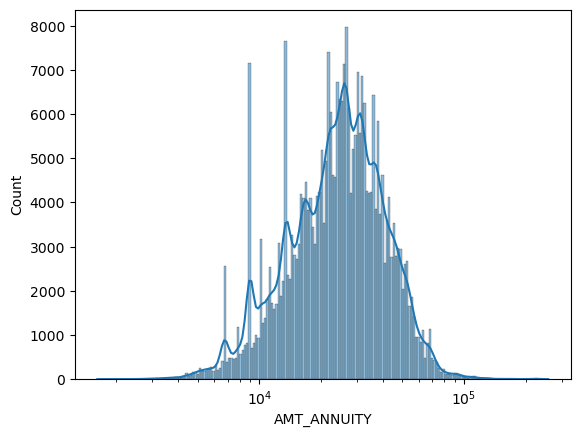

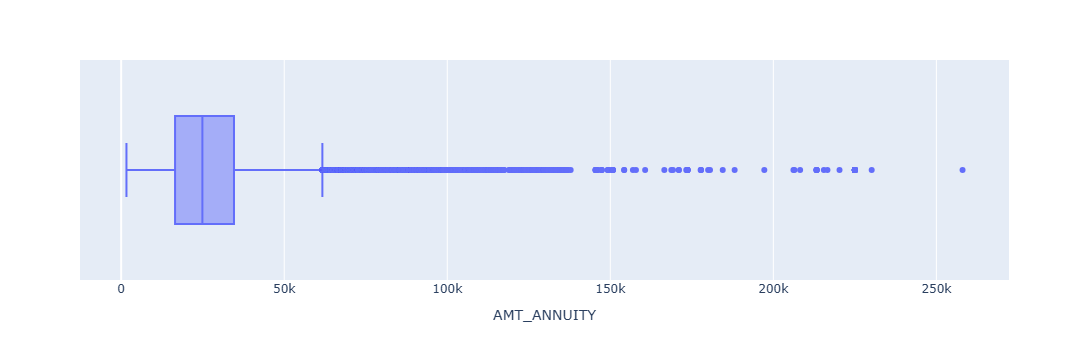

In [129]:
# HISTOGRAM E BOXPLOT, PARA VISUALISAR A DISTRIBUIÇÃO E OUTLIERS DA FEATURE
sns.histplot(features[numericas], x = 'AMT_ANNUITY', kde = True, bins = 200, stat = 'count', log_scale = True)
plt.show();
px.box(features[numericas], x = 'AMT_ANNUITY')

In [130]:
# VALOR DO SKER  ~0: OK, > 1: APLICAR LOG, > 2 ALTAMENTE RECOMENDADO
print(features['AMT_ANNUITY'].skew())

1.5798237246955467


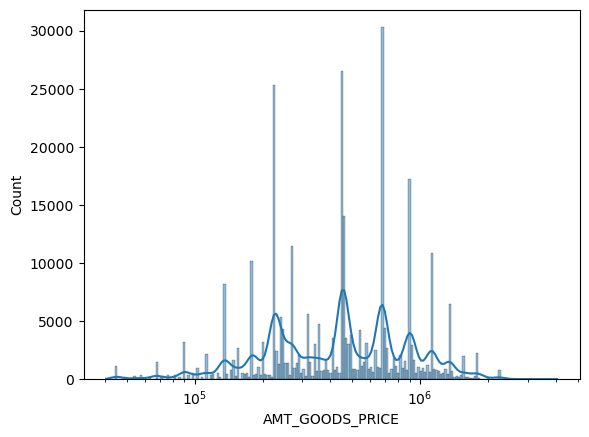

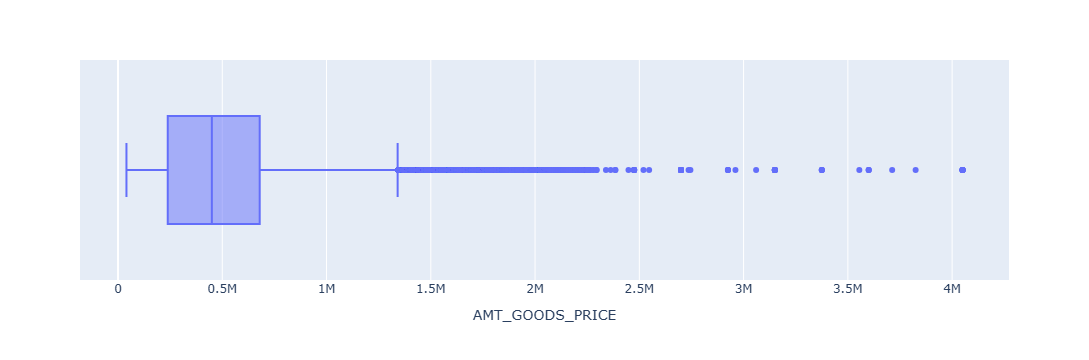

In [131]:
# HISTOGRAM E BOXPLOT, PARA VISUALISAR A DISTRIBUIÇÃO E OUTLIERS DA FEATUR
sns.histplot(features[numericas], x = 'AMT_GOODS_PRICE', kde = True, bins = 200, stat = 'count', log_scale = True)
plt.show()
px.box(features[numericas], x = 'AMT_GOODS_PRICE')

In [132]:
# VALOR DO SKER  ~0: OK, > 1: APLICAR LOG, > 2 ALTAMENTE RECOMENDADO
print(features['AMT_GOODS_PRICE'].skew())

1.3501425496350894


## Aplicaçao de LOG

In [133]:
# APLICANDO A ESCALA LOGARITMA NAS SEGUINTES FEATURES:
features['AMT_INCOME_TOTAL_log'] = np.log1p(features['AMT_INCOME_TOTAL'])
features['AMT_CREDIT_log'] = np.log1p(features['AMT_CREDIT'])
features['AMT_GOODS_PRICE_log'] = np.log1p(features['AMT_GOODS_PRICE'])
features['AMT_ANNUITY_log'] = np.log1p(features['AMT_ANNUITY']);
print(f'Formato da features pós criação das colunas aplicadas com LOG: {features.shape}')

Formato da features pós criação das colunas aplicadas com LOG: (307511, 192)


C:\Users\Rodrigo Brito\AppData\Local\Temp\ipykernel_21668\1333537138.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\Rodrigo Brito\AppData\Local\Temp\ipykernel_21668\1333537138.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\Rodrigo Brito\AppData\Local\Temp\ipykernel_21668\1333537138.py:4: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.

## Transformação das Variáveis Numéricas

Com base na análise exploratória, foram aplicadas transformações logarítmicas em variáveis selecionadas que apresentam assimetria positiva e presença de outliers.

Mesmo em casos onde a assimetria não era extremamento pronunciada, observou-se alta dispersão e valores extermos, justificando a aplicação da transformação para reduzir a influência desses valores e melhorar a estabilidade do modelo.

As variáveis transformadas foram mantidas em conjunto com suas versões originais, permitindo que o modelo explore diferentes represnetações dos dados

# 9. Tratamento de Variáveis Categóricas

As variáveis categóricas serão tratadas conforme sua cardinalidade, considerando estratégias como:
- One-Hot encondig para baixa cardinalidade
- Agrupamento de categorias raras

In [134]:
# CRIANDO AS VARAIVEIS DUMMIES DAS FEATURE CATEGORIAS 16 -> 130
features = pd.get_dummies(features, columns = categoricas, drop_first = True)

AttributeError: 'DataFrame' object has no attribute 'hed'

In [136]:
# INFORMAÇÕE DO DATASET PÓS CRIAÇÃO DAS DUMMIES
features.head()
features.shape
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 306 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_Yes
dtypes: bool(130), float64(109), int64(67)
memory usage: 451.0 MB


## Transformação das Variáveis Categóricas

As variáveis categóricas foram transformadas por meio da ténica de One-Hot Encoding utilizando a função 'get_dummies' do pandas.

Essa abordagem permite converter cetegorias textuais em variáveis numéricas binárias, possibilitando que modelos de machine learning capturem diferenças entre os perfis dos clientes.

Foi adotado o parâmetro 'drop_frist = True', deo forma a eveitar multicolinearidade entre as variáveis geradas (dummy variable trap), definido implicitamento uma categoria de referência para cada variável.

Embora o 'get_dummies' não seja a abordagem ideal para pipelines de produção, sua aplicação nesta etapa se mostra adequada para exploração e construção de modelos iniciais.

# 10. Criação de novas Variáveis (Feature Creation)

 Nesta seção são exploradas possíveis criações de novas variáveis a partir das informações existentes, como:
 - Razões entre renda e crédito
 - Indicadores binários derivados de variáveis originais
 - Combinações simples com signifcado de negócio

In [139]:
# SUBSTITUINDO 0 POR 1, ESSE VALOR CORRESPONDE AO NUMERO DE MEMBROS NA FAMILIA A SUBSTITUIÇÃO SERÁ FEITA PARA EVITAR A DIVISÃO INFINITA
features['CNT_FAM_MEMBERS'] = features['CNT_FAM_MEMBERS'].replace(0,1)

# QUANTO DA RENDA O CLIENTE ESTÁ COMPROMETENDO COM CRÉDITO
features['RATIO_CREDIT_INCOME'] = ( features['AMT_CREDIT'] / features['AMT_INCOME_TOTAL'])

# ESFORÇO MENSAL DE PAGAMENTO
features['RATIO_ANNUITY_INCOME'] = (features['AMT_ANNUITY'] / features['AMT_INCOME_TOTAL'])
# CREDITO POR MEMBRO FAMILIAR
features['CREDIT_PER_PERSON'] = (features['AMT_CREDIT'] / features['CNT_FAM_MEMBERS'])

# RENDA POR MEMBRO FAMILIAR
features['INCOME_PER_PERSON'] = (features['AMT_INCOME_TOTAL'] / features['CNT_FAM_MEMBERS'])

# RAZÃO CRÉDITO X BENS
features['RATIO_CREDIT_GOODS'] = (features['AMT_CREDIT'] / features['AMT_GOODS_PRICE'])


In [142]:
# FEATURES ATUALIZADO. 306 -> 311
features

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Unknown,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Unknown,EMERGENCYSTATE_MODE_Yes,RATIO_CREDIT_INCOME,RATIO_ANNUITY_INCOME,CREDIT_PER_PERSON,INCOME_PER_PERSON,RATIO_CREDIT_GOODS
0,100002.0,0.0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461.0,-637.0,-3648.0,...,True,False,False,False,False,2.007889,0.121978,406597.50,202500.0,1.158397
1,100003.0,0.0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765.0,-1188.0,-1186.0,...,False,False,False,False,False,4.790750,0.132217,646751.25,135000.0,1.145199
2,100004.0,0.0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046.0,-225.0,-4260.0,...,False,True,False,True,False,2.000000,0.100000,135000.00,67500.0,1.000000
3,100006.0,0.0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005.0,-3039.0,-9833.0,...,False,True,False,True,False,2.316167,0.219900,156341.25,67500.0,1.052803
4,100007.0,0.0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932.0,-3038.0,-4311.0,...,False,True,False,True,False,4.222222,0.179963,513000.00,121500.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251.0,0.0,157500.0,254700.0,27558.0,225000.0,0.032561,-9327.0,-236.0,-8456.0,...,True,False,False,False,False,1.617143,0.174971,254700.00,157500.0,1.132000
307507,456252.0,0.0,72000.0,269550.0,12001.5,225000.0,0.025164,-20775.0,365243.0,-4388.0,...,True,False,False,False,False,3.743750,0.166687,269550.00,72000.0,1.198000
307508,456253.0,0.0,153000.0,677664.0,29979.0,585000.0,0.005002,-14966.0,-7921.0,-6737.0,...,False,False,False,False,False,4.429176,0.195941,677664.00,153000.0,1.158400
307509,456254.0,0.0,171000.0,370107.0,20205.0,319500.0,0.005313,-11961.0,-4786.0,-2562.0,...,True,False,False,False,False,2.164368,0.118158,185053.50,85500.0,1.158394


## Criação de Novas Variáveis

Com o objetivo de melhorar a capacidade preditiva do modelo,
foram criadas novas variáveis a partir da combinação de atributos existentes.

As novas features foram desenvolvidas para representar de forma mais direta
o comportamento financeiro dos clientes, especialmente sua capacidade
de pagamento e nível de exposição ao crédito.

Destacam-se variáveis que relacionam renda, crédito e anuidade,
permitindo capturar relações que não são diretamente evidentes
nas variáveis originais.

Essa abordagem é amplamente utilizada em modelos de risco de crédito,
onde a relação entre variáveis é mais informativa do que seus valores absolutos.


# 11. Consolidação do Dataset Final para Modelagem

Após os tratamento realizados, as variáveis são consolidadas em um dataset final, pronto para ser utilizado na etapa de modelagem.

Nesta etapa são verificadas:
- Dimensão final do dataset
- Tipos de variáveis
- Presença residual de valores ausentes

In [166]:
# FORMATO FINAL DAS FEATURES
print(f'Formato Final do dataset: {features.shape}')

# QUANTIDADE DE NULOS 
print(f'Quantidade de valores nulos: {features.isnull().sum().sum()}')

# CONVERTENDO AS FEATURES DO TIPO BOOL PARA INT8
features = features.astype({col: 'int8' for col in features.select_dtypes('bool').columns})

# EXIBINDO OS TIPOS DAS FEATURES PRESENTE PÓS ENGENHARIA DE FEATURES
print(f'tipos das features: {features.dtypes.unique()}')

Formato Final do dataset: (307511, 311)
Quantidade de valores nulos: 0
tipos das features: [dtype('float64') dtype('int64') dtype('int8')]



## Consolidação do Dataset Final

Após as etapas de engenharia de variáveis, o dataset foi consolidado
em uma estrutura adequada para modelagem.

Foram realizadas verificações finais garantindo:
- Ausência de valores nulos
- Conversão completa para variáveis numéricas
- Manutenção da integridade do número de registros

O dataset final apresenta 307.511 observações e 311 variáveis,
incluindo transformações, variáveis derivadas e codificações categóricas.

Esse conjunto de dados será utilizado na etapa de modelagem,
com foco na construção de um modelo baseline para risco de crédito.


# 12. Salvamento do Dataset Processado

O dataset final é salvo localmente para uso nas etapas seguintes do projeto, garantindo reprodutibilidade e separação entre dados brutos e processados.

In [172]:
# SALVANDO A FEATURE E O TARGET PÓS PROCESSAMENTO
features.to_parquet('../data/processed/Features_processed.parquet')
target.to_frame().to_parquet('../data/processed/Target_processed.parquet')

# 13. Próximos Passos

Com o dataset preparado, o próximo passo do projeto será a construção de um modelo baseline para risco de crédito, utilizando técnicas de classificação supervisionada e métricas adequadas para classes desbalanceadas.